In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv(r"W:\Learn_Program\project_bigdata\Part_2\data\data.csv")

In [ ]:
rating_count = df["rating"].value_counts().sort_index()

rating_table = rating_count.to_frame("review_count")
rating_table["percentage"] = (
    rating_table["review_count"]
    / rating_table["review_count"].sum() * 100
).round(2)

display(rating_table)

,review_count,percentage
rating,,
1.0,3172,10.57
2.0,1488,4.96
3.0,1855,6.18
4.0,3225,10.75
5.0,20260,67.53


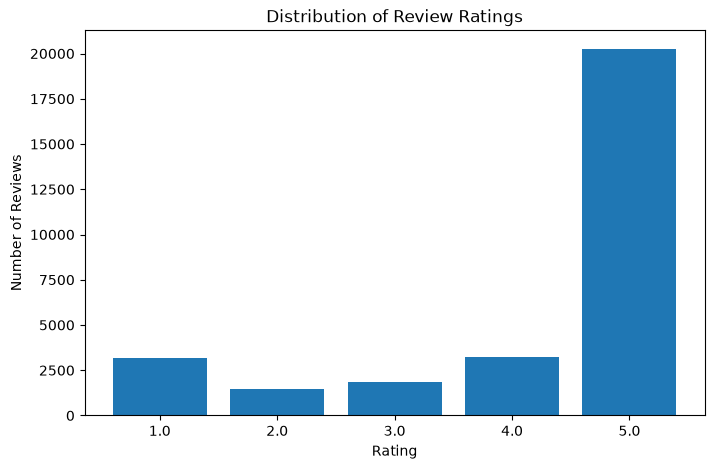

In [44]:
plt.figure(figsize=(8,5))

plt.bar(
    rating_table.index.astype(str),
    rating_table["review_count"]
)

plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Ratings")

plt.show()

In [80]:
product_review_count = (
    df.groupby(["parent_asin", "title_product"])
      .size()
      .reset_index(name="review_count")
)

display(product_review_count.head())

,parent_asin,title_product,review_count
0,0060883286,One Hundred Years of Solitude (Harper Perennia...,2
1,006121468X,"Ink Exchange (Wicked Lovely, 2)",1
2,0062427407,"Happy Valentine's Day, Mouse! Lap Edition (If ...",1
3,0310802636,"Adventure Bible Cover for Boys, Zippered, with...",1
4,0310803535,"Microfiber Red with Exterior Pockets, LG Bible...",1


In [81]:
low_review_products = (
    product_review_count[
        product_review_count["review_count"] < 3
    ]
    .sort_values("review_count")
)

display(low_review_products.head(20))

,parent_asin,title_product,review_count
20919,B0CGKN4H7Y,"2024 Planner - Planner 2024, Jan. 2024 - Dec. ...",1
20918,B0CGK35GKQ,"Pendaflex Divide It Up File Folders, Letter Si...",1
20917,B0CGJ71K5Z,"Giikin Vinyl Record Storage Holder, Holds up t...",1
20916,B0CGCT1ZBG,Upgraded Large Size Magic Practice Copybook fo...,1
20915,B0CG5S5Z97,"MaxGear 2"" Office Chair Wheels Heavy Duty Repl...",1
21,0545301807,Scholastic Teacher's Friend Alphabet (upper- a...,1
20,0545227526,Cursive Writing Practice: Jokes & Riddles,1
19,0545161177,Scholastic Teacher's Friend Notable African Am...,1
18,0545119243,Month-by-Month Clip Art,1
17,054511828X,Scholastic Primary Math Charts Bulletin Board ...,1


In [82]:
num_low_review_products = len(low_review_products)

print(
    f"จำนวน Product ที่มี Review น้อยกว่า 3: "
    f"{num_low_review_products:,} Product"
)

จำนวน Product ที่มี Review น้อยกว่า 3: 19,286 Product


In [83]:
low_review_summary = (
    low_review_products["review_count"]
    .value_counts()
    .sort_index()
)

display(
    low_review_summary.rename("number_of_products")
)

review_count
1    16875
2     2411
Name: number_of_products, dtype: int64

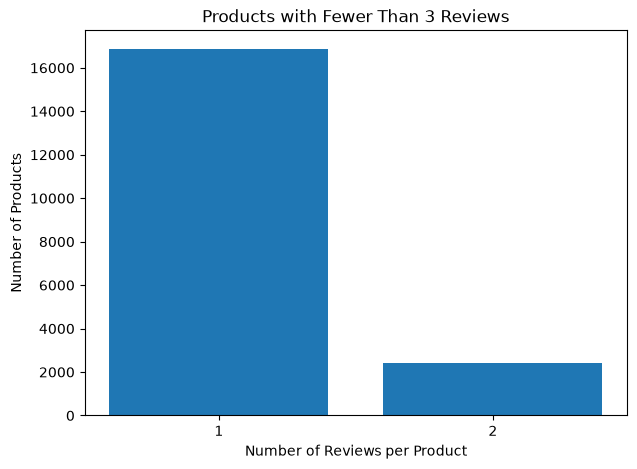

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    low_review_summary.index.astype(str),
    low_review_summary.values
)

plt.xlabel("Number of Reviews per Product")
plt.ylabel("Number of Products")
plt.title("Products with Fewer Than 3 Reviews")

plt.show()

In [85]:
total_products = len(product_review_count)

low_review_percentage = (
    len(low_review_products) / total_products * 100
)

print(f"Product ทั้งหมด: {total_products:,}")
print(f"Product ที่มี Review < 3: {len(low_review_products):,}")
print(f"คิดเป็น: {low_review_percentage:.2f}%")

Product ทั้งหมด: 20,933
Product ที่มี Review < 3: 19,286
คิดเป็น: 92.13%
